# Point-sampling sensitivity: sample size vs. disturbance rate

Multi-run experiment: how does Olofsson-based area estimation and corrected F1 compare to
full pixel-level F1 across a range of sample sizes and disturbance rates?

**Experiment config:** `interpreter/experiments/configs/point_sampling_sensitivity.json`  
**Base sensor config:** `interpreter/experiments/configs/map_comparison_point_vs_all.json`  
**Log:** `interpreter/experiment_logs/master_experiment_logger.csv`

Sections:
1. Run experiment (loop over conditions × runs, log to CSV)
2. Load results from CSV
3. Figure: CI width vs sample size
4. Figure: Area estimate bias
5. Figure: Pixel F1 vs sample F1
6. Figure: Effect of disturbance rate

In [ ]:
import sys, os, json, copy, csv

def find_project_root(marker='.git', start=None):
    """Walk upward from `start` (default: cwd) until `marker` is found.

    Jupyter kernel CWD for this notebook varies by machine/VS Code settings
    (sometimes the repo root, sometimes interpreter/notebooks/) — searching
    for a marker that only exists at the true root makes PROJ_ROOT immune
    to that.
    """
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(f"Could not find project root (marker: {marker!r}) above {start or os.getcwd()}")
        path = parent

PROJ_ROOT = find_project_root()
sys.path.insert(0, os.path.join(PROJ_ROOT, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from landscape_stack_collection import LandscapeStackCollection
from map_comparison import pixel_level_metrics_for_collection
from disturbance_helper_functions import generate_run_id

In [ ]:
with open(os.path.join(PROJ_ROOT, 'interpreter/experiments/configs/point_sampling_sensitivity.json')) as f:
    exp_cfg = json.load(f)
with open(os.path.join(PROJ_ROOT, exp_cfg['base_config'])) as f:
    base_cfg = json.load(f)

EXPERIMENT_NAME = exp_cfg['experiment_name']
LOG_DIR         = os.path.join(PROJ_ROOT, exp_cfg['log_dir'])
os.makedirs(LOG_DIR, exist_ok=True)
MASTER_LOG_PATH = os.path.join(LOG_DIR, 'master_experiment_logger.csv')

n_cond  = len(exp_cfg['conditions'])
n_runs  = exp_cfg['n_runs_per_condition']
print(f'Experiment:  {EXPERIMENT_NAME}')
print(f'Conditions:  {n_cond}  x  {n_runs} runs  =  {n_cond * n_runs} total runs')
print(f'Conditions:  {[c["condition_id"] for c in exp_cfg["conditions"]]}')
print(f'Log:         {MASTER_LOG_PATH}')

In [3]:
RESULT_COLUMNS = [
    'run_id', 'experiment_name', 'condition_id', 'run_number', 'sensor_name',
    'n_train_stacks', 'n_val_stacks',
    'n_samples_per_class_0', 'n_samples_per_class_1',
    'catastrophic_prob_type1', 'catastrophic_prob_type2',
    'p_hat', 'se', 'ci_lo', 'ci_hi', 'true_disturbed_prop',
    'f1_pixel', 'f1_sample', 'n_class0', 'n_class1',
    'pixel_agreement', 'pixel_precision', 'pixel_recall', 'pixel_iou',
]


def corrected_f1_from_olofsson(olf: dict) -> float:
    """F1 for class 1 from Olofsson-weighted confusion proportions."""
    W, p_ij = olf['W'], olf['p_ij']
    TP    = W[1] * p_ij[1, 1]
    FP    = W[1] * p_ij[1, 0]
    FN    = W[0] * p_ij[0, 1]
    denom = 2 * TP + FP + FN
    return float(2 * TP / denom) if denom > 0 else float('nan')


def append_run_rows(rows: list, path: str) -> None:
    """Append one run's rows to the master CSV, writing header if the file is new."""
    file_exists = os.path.exists(path)
    with open(path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=RESULT_COLUMNS, extrasaction='ignore')
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)

## 1. Run experiment

Each iteration: deepcopy base config → apply condition overrides → build train/val collections
→ train classifiers → compute pixel-level metrics + Olofsson sample → log to CSV.

Results are also accumulated in `all_rows` for immediate analysis below.
If the experiment has already been run, skip this cell and go to Section 2 to load from CSV.

In [4]:
all_rows    = []
total_runs  = n_cond * n_runs
run_counter = 0

for c_idx, cond in enumerate(exp_cfg['conditions']):
    cond_id   = cond['condition_id']
    cat_prob  = cond['catastrophic_probability']
    n_samp    = cond['n_samples_per_class']
    n_spc_int = {int(k): v for k, v in n_samp.items()}

    for run_num in range(n_runs):
        run_counter += 1
        run_id = generate_run_id()
        print(f'[{run_counter}/{total_runs}]  cond={cond_id}  run={run_num+1}/{n_runs}  id={run_id}')

        # Deep-copy base config and apply condition overrides
        cfg   = copy.deepcopy(base_cfg)
        cfg['training_experiment_config']['n_stacks']   = cond['n_train_stacks']
        cfg['validation_experiment_config']['n_stacks'] = cond['n_val_stacks']

        types = cfg['landscape_stack_config']['disturbance_config']['types']
        types['type1']['proportional_loss']['mixture']['catastrophic_probability'] = cat_prob['type1']
        types['type2']['proportional_loss']['mixture']['catastrophic_probability'] = cat_prob['type2']

        cfg['point_sample_config']['n_samples_per_class'] = n_samp

        # Vary seeds by condition+run so each replicate sees different landscapes
        seed_offset = c_idx * n_runs + run_num
        cfg['training_experiment_config']['patch_selection_seed']    = 42    + seed_offset
        cfg['training_experiment_config']['disturbance_seed_base']   = 1000  + seed_offset * 500
        cfg['validation_experiment_config']['patch_selection_seed']  = 10000 + seed_offset
        cfg['validation_experiment_config']['disturbance_seed_base'] = 50000 + seed_offset * 500

        stack_cfg     = cfg['landscape_stack_config']
        train_exp_cfg = dict(cfg['training_experiment_config'])
        val_exp_cfg   = dict(cfg['validation_experiment_config'])
        train_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, train_exp_cfg['patch_dir'])
        val_exp_cfg['patch_dir']   = os.path.join(PROJ_ROOT, val_exp_cfg['patch_dir'])
        bc_cfg        = cfg['binary_classifier_config']
        SENSOR_NAMES  = [s['name'] for s in stack_cfg['sensors']]

        # Training collection
        train_col = LandscapeStackCollection.from_config(
            stack_template_cfg=stack_cfg, experiment_cfg=train_exp_cfg)
        train_col.buildBinaryClassifier(
            sensor_names=bc_cfg['sensor_names'],
            n_strata=bc_cfg['n_strata'],
            samples_per_stratum=bc_cfg['samples_per_stratum'],
            sampling_seed=bc_cfg['sampling_seed'],
            fp_to_fn_ratio=bc_cfg['fp_to_fn_ratio'],
        )
        train_col.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

        # Validation collection (disjoint from training)
        used_tifs = [s.base_landscape.tif_path for s in train_col.stacks]
        val_col = LandscapeStackCollection.from_config(
            stack_template_cfg=stack_cfg, experiment_cfg=val_exp_cfg,
            exclude_tif_paths=used_tifs)
        val_col.loadBinaryModel(train_col.binary_models)
        val_col.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

        # Pixel-level metrics averaged over validation stacks
        pixel_df = pixel_level_metrics_for_collection(val_col, sensor_names=SENSOR_NAMES)
        pixel_summary = pixel_df.groupby('sensor_name')[
            ['agreement', 'precision', 'recall', 'f1', 'iou']
        ].mean()

        # Olofsson point sample + corrected F1 per sensor
        run_rows = []
        for sensor_name in SENSOR_NAMES:
            samples = val_col.binary_stratified_sample(
                sensor_name=sensor_name,
                n_samples_per_class=n_spc_int,
                sampling_seed=None,
            )
            olf = val_col.olofsson_area_estimates(samples, sensor_name=sensor_name)
            px  = pixel_summary.loc[sensor_name]

            run_rows.append({
                'run_id':                   run_id,
                'experiment_name':          EXPERIMENT_NAME,
                'condition_id':             cond_id,
                'run_number':               run_num + 1,
                'sensor_name':              sensor_name,
                'n_train_stacks':           cond['n_train_stacks'],
                'n_val_stacks':             cond['n_val_stacks'],
                'n_samples_per_class_0':    n_samp['0'],
                'n_samples_per_class_1':    n_samp['1'],
                'catastrophic_prob_type1':  cat_prob['type1'],
                'catastrophic_prob_type2':  cat_prob['type2'],
                'p_hat':                    float(olf['P_hat'][1]),
                'se':                       float(olf['SE'][1]),
                'ci_lo':                    float(olf['CI']['lower'][1]),
                'ci_hi':                    float(olf['CI']['upper'][1]),
                'true_disturbed_prop':      float(olf['true_disturbed_prop']),
                'f1_sample':                corrected_f1_from_olofsson(olf),
                'f1_pixel':                 float(px['f1']),
                'n_class0':                 int(olf['n_i_samples'][0]),
                'n_class1':                 int(olf['n_i_samples'][1]),
                'pixel_agreement':          float(px['agreement']),
                'pixel_precision':          float(px['precision']),
                'pixel_recall':             float(px['recall']),
                'pixel_iou':                float(px['iou']),
            })

        all_rows.extend(run_rows)
        append_run_rows(run_rows, MASTER_LOG_PATH)

print(f'\nDone. {len(all_rows)} rows written to {MASTER_LOG_PATH}')

[1/90]  cond=n50_distLow  run=1/10  id=run_ID_20260727_171744_63613e


/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/./src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


[2/90]  cond=n50_distLow  run=2/10  id=run_ID_20260727_171819_45c49c


/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/./src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


[3/90]  cond=n50_distLow  run=3/10  id=run_ID_20260727_171902_4d11a5


...

[89/90]  cond=n200_distHigh  run=9/10  id=run_ID_20260727_181300_d5f06d


/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/./src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


[90/90]  cond=n200_distHigh  run=10/10  id=run_ID_20260727_181334_f8ad93


/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/./src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))



Done. 360 rows written to ./interpreter/experiment_logs/master_experiment_logger.csv


## 2. Load results from CSV

Run this cell to load results from a previous experiment run (or after the loop above).

In [5]:
results_df = pd.read_csv(MASTER_LOG_PATH)
results_df = results_df[results_df['experiment_name'] == EXPERIMENT_NAME].copy()

results_df['ci_width']   = results_df['ci_hi'] - results_df['ci_lo']
results_df['area_error'] = results_df['p_hat'] - results_df['true_disturbed_prop']
results_df['n_samp']     = results_df['n_samples_per_class_0']   # symmetric per class

print(f'{len(results_df)} rows  |  {results_df["run_id"].nunique()} unique runs')
print(f'Conditions: {results_df["condition_id"].unique().tolist()}')
print(f'Sensors:    {results_df["sensor_name"].unique().tolist()}')
results_df.head()

360 rows  |  90 unique runs
Conditions: ['n50_distLow', 'n50_distMed', 'n50_distHigh', 'n100_distLow', 'n100_distMed', 'n100_distHigh', 'n200_distLow', 'n200_distMed', 'n200_distHigh']
Sensors:    ['Sensor_Clean', 'Sensor_X', 'Sensor_Y', 'Sensor_Z']


,run_id,experiment_name,condition_id,run_number,sensor_name,n_train_stacks,n_val_stacks,n_samples_per_class_0,n_samples_per_class_1,catastrophic_prob_type1,...,f1_sample,n_class0,n_class1,pixel_agreement,pixel_precision,pixel_recall,pixel_iou,ci_width,area_error,n_samp
0,run_ID_20260727_171744_63613e,point_sampling_sensitivity,n50_distLow,1,Sensor_Clean,20,40,50,50,0.01,...,0.969072,50,50,0.999243,0.921692,0.985045,0.906737,0.001125,0.000153,50
1,run_ID_20260727_171744_63613e,point_sampling_sensitivity,n50_distLow,1,Sensor_X,20,40,50,50,0.01,...,0.823529,50,50,0.995957,0.681989,0.813956,0.580603,0.002369,-0.001338,50
2,run_ID_20260727_171744_63613e,point_sampling_sensitivity,n50_distLow,1,Sensor_Y,20,40,50,50,0.01,...,0.360656,50,50,0.978936,0.245422,0.535380,0.190623,0.005066,-0.002996,50
3,run_ID_20260727_171744_63613e,point_sampling_sensitivity,n50_distLow,1,Sensor_Z,20,40,50,50,0.01,...,0.072104,50,50,0.963424,0.101033,0.274530,0.073005,0.059285,0.013481,50
4,run_ID_20260727_171819_45c49c,point_sampling_sensitivity,n50_distLow,2,Sensor_Clean,20,40,50,50,0.01,...,1.000000,50,50,0.999747,1.000000,0.974940,0.974940,0.000000,-0.000262,50


## 3. CI width vs sample size

Does increasing samples narrow the Olofsson CI enough to distinguish maps?

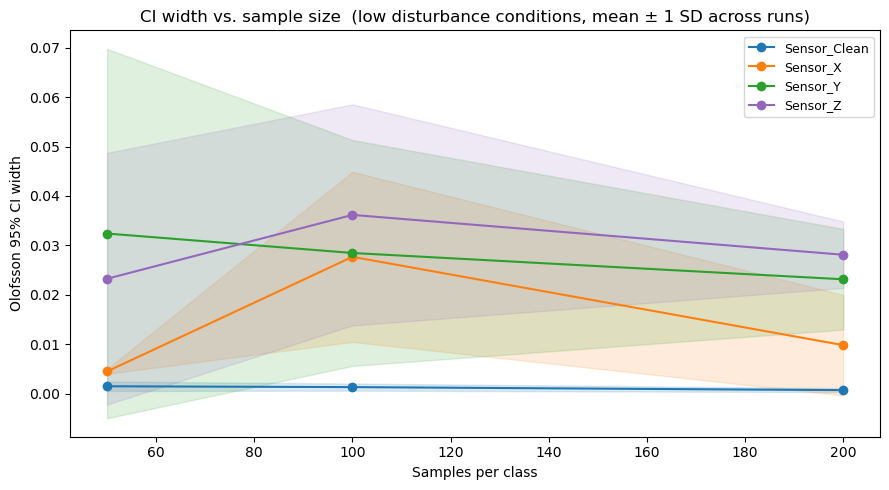

In [6]:
# Filter to low-disturbance conditions only (same catastrophic_prob)
dist_low = results_df[results_df['catastrophic_prob_type1'] == 0.02].copy()
sensors  = results_df['sensor_name'].unique()
colors   = plt.cm.tab10(np.linspace(0, 0.4, len(sensors)))
color_map = dict(zip(sensors, colors))

fig, ax = plt.subplots(figsize=(9, 5))

for sensor, grp in dist_low.groupby('sensor_name'):
    stats = grp.groupby('n_samp')['ci_width'].agg(['mean', 'std'])
    ax.plot(stats.index, stats['mean'], 'o-', color=color_map[sensor],
            label=sensor, lw=1.5, ms=6)
    ax.fill_between(stats.index,
                    stats['mean'] - stats['std'],
                    stats['mean'] + stats['std'],
                    alpha=0.15, color=color_map[sensor])

ax.set_xlabel('Samples per class')
ax.set_ylabel('Olofsson 95% CI width')
ax.set_title('CI width vs. sample size  (low disturbance conditions, mean ± 1 SD across runs)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. Area estimate bias

`p_hat − true_disturbed_prop` across sample sizes and sensors. Should be centred on 0.

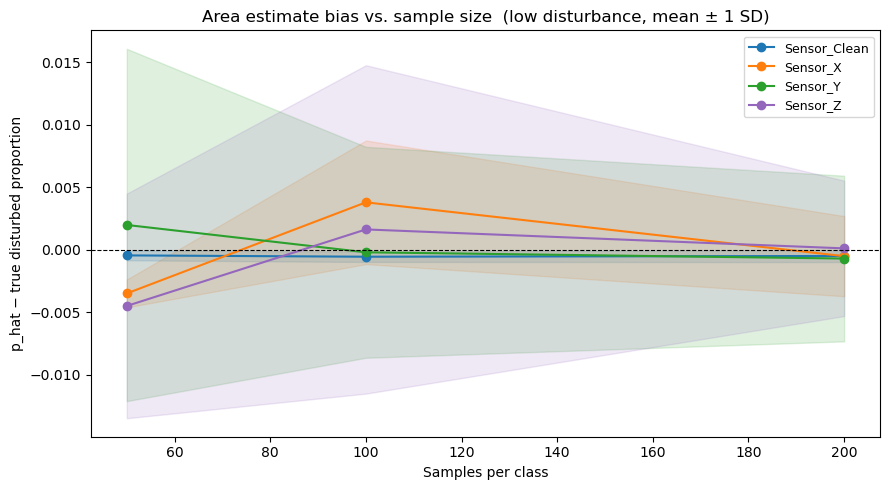

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for sensor, grp in dist_low.groupby('sensor_name'):
    stats = grp.groupby('n_samp')['area_error'].agg(['mean', 'std'])
    ax.plot(stats.index, stats['mean'], 'o-', color=color_map[sensor],
            label=sensor, lw=1.5, ms=6)
    ax.fill_between(stats.index,
                    stats['mean'] - stats['std'],
                    stats['mean'] + stats['std'],
                    alpha=0.15, color=color_map[sensor])

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Samples per class')
ax.set_ylabel('p_hat − true disturbed proportion')
ax.set_title('Area estimate bias vs. sample size  (low disturbance, mean ± 1 SD)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 5. Pixel F1 vs sample F1

Core diagnostic: does the corrected sample F1 track the pixel-level F1?
Each point is one (run × sensor). Color = sensor, shape = disturbance condition.
If the 1:1 line is followed, samples reliably rank maps in the same order as the true pixel metric.

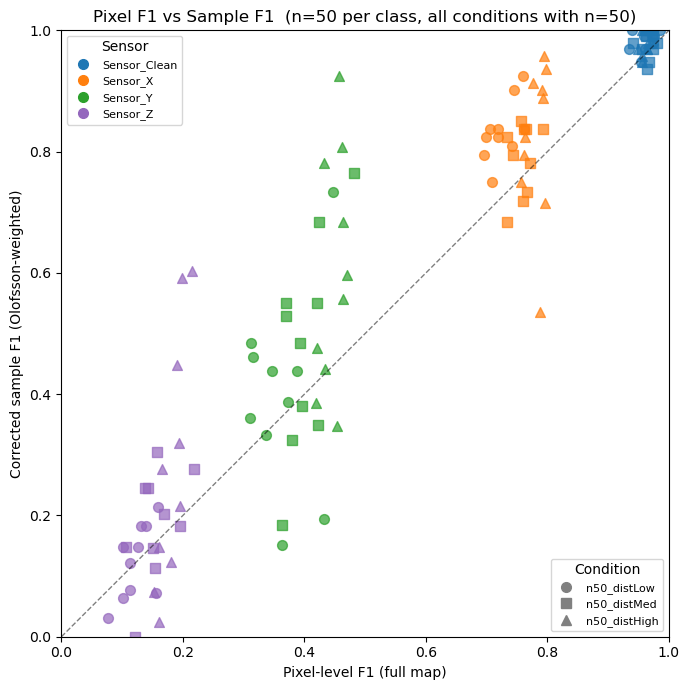

In [8]:
# Subset to n=50 per class (the 'standard' sample size) to avoid sample-size confound
sub = results_df[results_df['n_samp'] == 50].copy()

markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
cond_ids = sub['condition_id'].unique()
marker_map = {c: markers[i % len(markers)] for i, c in enumerate(cond_ids)}

fig, ax = plt.subplots(figsize=(7, 7))

for sensor, sgrp in sub.groupby('sensor_name'):
    for cond_id, cgrp in sgrp.groupby('condition_id'):
        ax.scatter(
            cgrp['f1_pixel'], cgrp['f1_sample'],
            color=color_map[sensor], marker=marker_map[cond_id],
            s=50, alpha=0.7,
            label=f'{sensor} | {cond_id}' if (sensor == sensors[0]) else '_',
        )

# 1:1 reference
lo, hi = 0.0, 1.0
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='1:1')

# Sensor legend
sensor_handles = [
    mlines.Line2D([], [], color=color_map[s], marker='o', ls='', ms=7, label=s)
    for s in sensors
]
# Condition legend
cond_handles = [
    mlines.Line2D([], [], color='gray', marker=marker_map[c], ls='', ms=7, label=c)
    for c in cond_ids
]
leg1 = ax.legend(handles=sensor_handles, title='Sensor', fontsize=8, loc='upper left')
ax.add_artist(leg1)
ax.legend(handles=cond_handles, title='Condition', fontsize=8, loc='lower right')

ax.set_xlabel('Pixel-level F1 (full map)')
ax.set_ylabel('Corrected sample F1 (Olofsson-weighted)')
ax.set_title(f'Pixel F1 vs Sample F1  (n=50 per class, all conditions with n=50)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
fig.tight_layout()
plt.show()

## 6. Effect of disturbance rate

Fix sample size at n=50 per class, vary `catastrophic_probability`. Does higher disturbance
rate make the sample-based estimate more or less reliable?

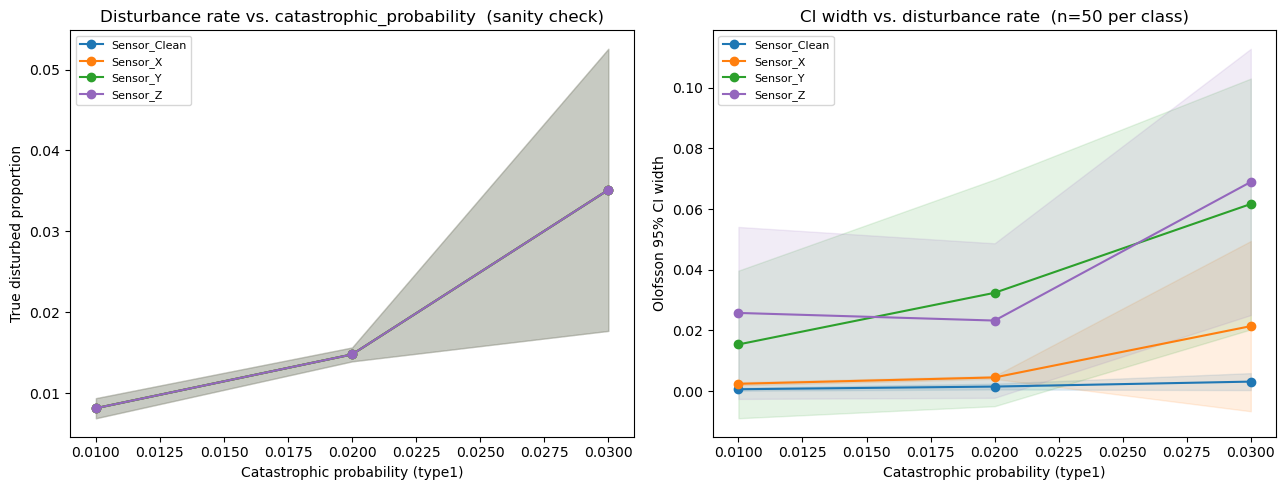

In [9]:
# Conditions with n=50 per class, varying disturbance rate
n50 = results_df[results_df['n_samp'] == 50].copy()
n50['dist_label'] = n50['catastrophic_prob_type1'].apply(lambda p: f'catProb={p:.2f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: true disturbance proportion vs. catastrophic prob (sanity check)
for sensor, grp in n50.groupby('sensor_name'):
    stats = grp.groupby('catastrophic_prob_type1')['true_disturbed_prop'].agg(['mean', 'std'])
    ax1.plot(stats.index, stats['mean'], 'o-', color=color_map[sensor], label=sensor, lw=1.5)
    ax1.fill_between(stats.index, stats['mean'] - stats['std'],
                     stats['mean'] + stats['std'], alpha=0.12, color=color_map[sensor])
ax1.set_xlabel('Catastrophic probability (type1)')
ax1.set_ylabel('True disturbed proportion')
ax1.set_title('Disturbance rate vs. catastrophic_probability  (sanity check)')
ax1.legend(fontsize=8)

# Right: CI width vs disturbance rate
for sensor, grp in n50.groupby('sensor_name'):
    stats = grp.groupby('catastrophic_prob_type1')['ci_width'].agg(['mean', 'std'])
    ax2.plot(stats.index, stats['mean'], 'o-', color=color_map[sensor], label=sensor, lw=1.5)
    ax2.fill_between(stats.index, stats['mean'] - stats['std'],
                     stats['mean'] + stats['std'], alpha=0.12, color=color_map[sensor])
ax2.set_xlabel('Catastrophic probability (type1)')
ax2.set_ylabel('Olofsson 95% CI width')
ax2.set_title('CI width vs. disturbance rate  (n=50 per class)')
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. Summary table

In [10]:
summary = (
    results_df
    .groupby(['condition_id', 'n_samp', 'catastrophic_prob_type1', 'sensor_name'])
    [['true_disturbed_prop', 'p_hat', 'ci_width', 'area_error', 'f1_pixel', 'f1_sample']]
    .agg(['mean', 'std'])
    .round(4)
)
summary

true_disturbed_prop  \
                                                                         mean   
condition_id  n_samp catastrophic_prob_type1 sensor_name                        
n100_distHigh 100    0.03                    Sensor_Clean              0.0305   
                                             Sensor_X                  0.0305   
                                             Sensor_Y                  0.0305   
                                             Sensor_Z                  0.0305   
n100_distLow  100    0.01                    Sensor_Clean              0.0138   
                                             Sensor_X                  0.0138   
                                             Sensor_Y                  0.0138   
                                             Sensor_Z                  0.0138   
n100_distMed  100    0.02                    Sensor_Clean              0.0218   
                                             Sensor_X                  0.0218   
                                             Sensor_Y                  0.0218   
                                             Sensor_Z                  0.0218   
n200_distHigh 200    0.03                    Sensor_Clean              0.0337   
                                             Sensor_X                  0.0337   
                                             Sensor_Y                  0.0337   
                                             Sensor_Z                  0.0337   
n200_distLow  200    0.01                    Sensor_Clean              0.0131   
                                             Sensor_X                  0.0131   
                                             Sensor_Y                  0.0131   
                                             Sensor_Z                  0.0131   
n200_distMed  200    0.02                    Sensor_Clean              0.0171   
                                             Sensor_X                  0.0171   
                                             Sensor_Y                  0.0171   
                                             Sensor_Z                  0.0171   
n50_distHigh  50     0.03                    Sensor_Clean              0.0351   
                                             Sensor_X                  0.0351   
                                             Sensor_Y                  0.0351   
                                             Sensor_Z                  0.0351   
n50_distLow   50     0.01                    Sensor_Clean              0.0081   
                                             Sensor_X                  0.0081   
                                             Sensor_Y                  0.0081   
                                             Sensor_Z                  0.0081   
n50_distMed   50     0.02                    Sensor_Clean              0.0148   
                                             Sensor_X                  0.0148   
                                             Sensor_Y                  0.0148   
                                             Sensor_Z                  0.0148   

                                                                    p_hat  \
                                                              std    mean   
condition_id  n_samp catastrophic_prob_type1 sensor_name                    
n100_distHigh 100    0.03                    Sensor_Clean  0.0120  0.0297   
                                             Sensor_X      0.0120  0.0314   
                                             Sensor_Y      0.0120  0.0342   
                                             Sensor_Z      0.0120  0.0320   
n100_distLow  100    0.01                    Sensor_Clean  0.0097  0.0136   
                                             Sensor_X      0.0097  0.0133   
                                             Sensor_Y      0.0097  0.0134   
                                             Sensor_Z      0.0097  0.0123   
n100_distMed  100    0.02                    Sensor